# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Franco Marcelo Morero

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 7 de agosto (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dLacTc6eZMWjWGZJA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP2-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

### Carga de datos e inspección inicial

Arranco cargando los dos archivos ya separados (adult_train.csv y adult_val.csv) y mirando forma, tipos y primeras filas. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
train = pd.read_csv("adult_train.csv")
val = pd.read_csv("adult_val.csv")

print(f"train: {train.shape}")
print(f"val:   {val.shape}")

train: (30162, 14)
val:   (15060, 14)


In [3]:
train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB


In [5]:
nulos = pd.DataFrame({
    "n_nulos": train.isna().sum(),
    "pct_nulos": (train.isna().mean() * 100).round(2),
})
print(nulos.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [6]:
nulos_val = pd.DataFrame({
    "n_nulos": val.isna().sum(),
    "pct_nulos": (val.isna().mean() * 100).round(2),
})
print(nulos_val.sort_values("n_nulos", ascending=False))

                n_nulos  pct_nulos
age                   0        0.0
workclass             0        0.0
education             0        0.0
marital-status        0        0.0
occupation            0        0.0
relationship          0        0.0
race                  0        0.0
sex                   0        0.0
capital-gain          0        0.0
capital-loss          0        0.0
hours-per-week        0        0.0
skill-profile         0        0.0
native-country        0        0.0
income                0        0.0


In [7]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,30162.0,NaN,NaN,NaN,38.437902,13.134665,17.0,28.0,37.0,47.0,90.0
workclass,30162,7,Private,22286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,30162,16,HS-grad,9840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,30162,7,Married-civ-spouse,14065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,30162,14,Prof-specialty,4038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,30162,6,Husband,12463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,30162,5,White,25933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,30162,2,Male,20380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,30162.0,NaN,NaN,NaN,1092.007858,7406.346497,0.0,0.0,0.0,0.0,99999.0
capital-loss,30162.0,NaN,NaN,NaN,88.372489,404.29837,0.0,0.0,0.0,0.0,4356.0


In [8]:
train.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     41
age                72
skill-profile      80
capital-loss       90
hours-per-week     94
capital-gain      118
dtype: int64

In [9]:
val.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,15060.0,NaN,NaN,NaN,38.768327,13.380676,17.0,28.0,37.0,48.0,90.0
workclass,15060,7,Private,11021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,15060,16,HS-grad,4943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital-status,15060,7,Married-civ-spouse,6990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,15060,14,Exec-managerial,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,15060,6,Husband,6203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,15060,5,White,12970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,15060,2,Male,10147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,15060.0,NaN,NaN,NaN,1120.301594,7703.181842,0.0,0.0,0.0,0.0,99999.0
capital-loss,15060.0,NaN,NaN,NaN,89.041899,406.283245,0.0,0.0,0.0,0.0,3770.0


In [10]:
val.nunique().sort_values()

sex                 2
income              2
race                5
relationship        6
workclass           7
marital-status      7
occupation         14
education          16
native-country     40
age                73
capital-loss       79
skill-profile      80
hours-per-week     89
capital-gain      110
dtype: int64

In [11]:
print("duplicados train:", train.duplicated().sum())
print("duplicados val:  ", val.duplicated().sum())

duplicados train: 479
duplicados val:   118


In [12]:
# consistencia de categorias entre train y val, 
# para que no nos falten al crear el vocabulario de los embeddings
cat_cols = [c for c in train.select_dtypes("object").columns if c != "income"]
print("\ncategorias presentes en val y ausentes en train:")
hay = False
for c in cat_cols:
    faltan = set(val[c].unique()) - set(train[c].unique())
    if faltan:
        hay = True
        print(f"  {c}: {faltan}")
if not hay:
    print("  ninguna (val no aporta categorias nuevas)")


categorias presentes en val y ausentes en train:
  ninguna (val no aporta categorias nuevas)


Observaciones iniciales

El dataset tiene 14 columnas y ninguna fila con nulos. Hay algunos pocos duplicados. 

Agrupo las variables por lo que representan:

- **Demográficas:** age, sex, race, native-country, marital-status, relationship.
- **Laborales / educativas:** workclass, occupation, education, skill-profile, hours-per-week.
- **Financieras:** capital-gain, capital-loss.
- **Objetivo:** income (binaria, <=50K / >50K).

Cuatro columnas son numéricas enteras (age, capital-gain, capital-loss, hours-per-week) y el resto son categóricas de tipo texto. 

Se puede ve que la cardinalidad varía mucho entre categóricas, teniendo desde sex con 2 valores hasta skill-profile con 80. 

El dataset de de validación no contiene ninguna categoría que no esté en entrenamiento. Es bueno porque cualquier vocabulario para embeddings que arme sobre train cubre a las categorias en validación.

### Variable objetivo income

Miro la distribución de la clase en train y val. 

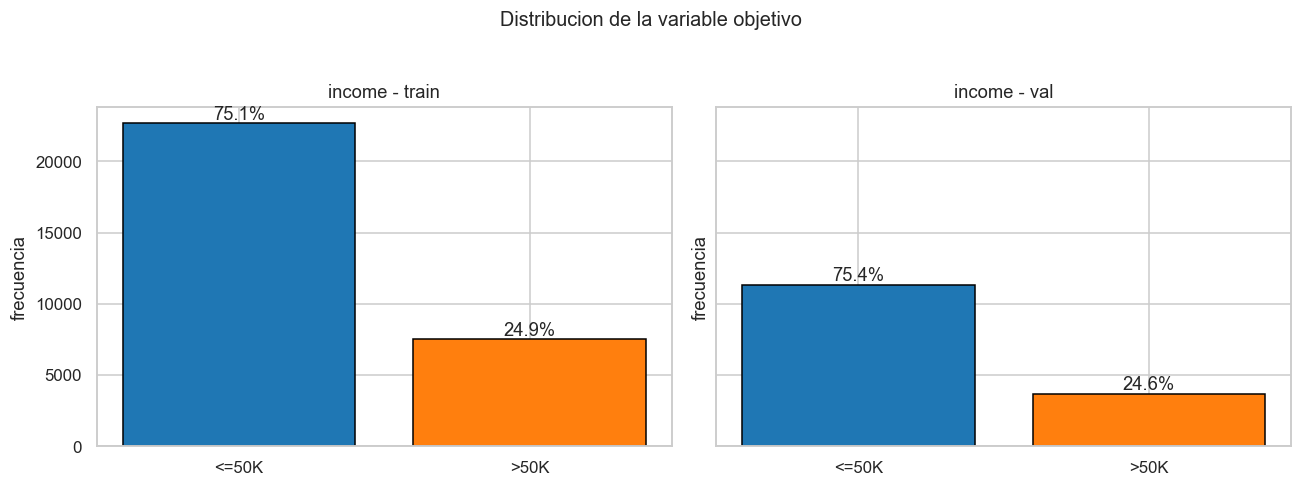

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (nombre, d) in zip(axes, [("train", train), ("val", val)]):
    vc = d["income"].value_counts()
    pct = d["income"].value_counts(normalize=True) * 100
    bars = ax.bar(vc.index, vc.values, color=["tab:blue", "tab:orange"], edgecolor="black")
    for b, p in zip(bars, pct):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f"{p:.1f}%", ha="center", va="bottom")
    ax.set_title(f"income - {nombre}")
    ax.set_ylabel("frecuencia")
fig.suptitle("Distribucion de la variable objetivo", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

La clase está desbalanceada, alrededor del 75% de las personas gana <=50K y solo un 25% gana >50K. La proporción es prácticamente igual en train y en val, así que la partición de los datos es correcta.

### Variables numéricas

In [14]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

stats = pd.DataFrame({
    "media": train[num_cols].mean(),
    "mediana": train[num_cols].median(),
    "moda": [train[c].mode().iloc[0] for c in num_cols],
    "std": train[num_cols].std(),
    "min": train[num_cols].min(),
    "max": train[num_cols].max(),
}).round(2)
stats

,media,mediana,moda,std,min,max
age,38.44,37.0,36,13.13,17,90
capital-gain,1092.01,0.0,0,7406.35,0,99999
capital-loss,88.37,0.0,0,404.30,0,4356
hours-per-week,40.93,40.0,40,11.98,1,99


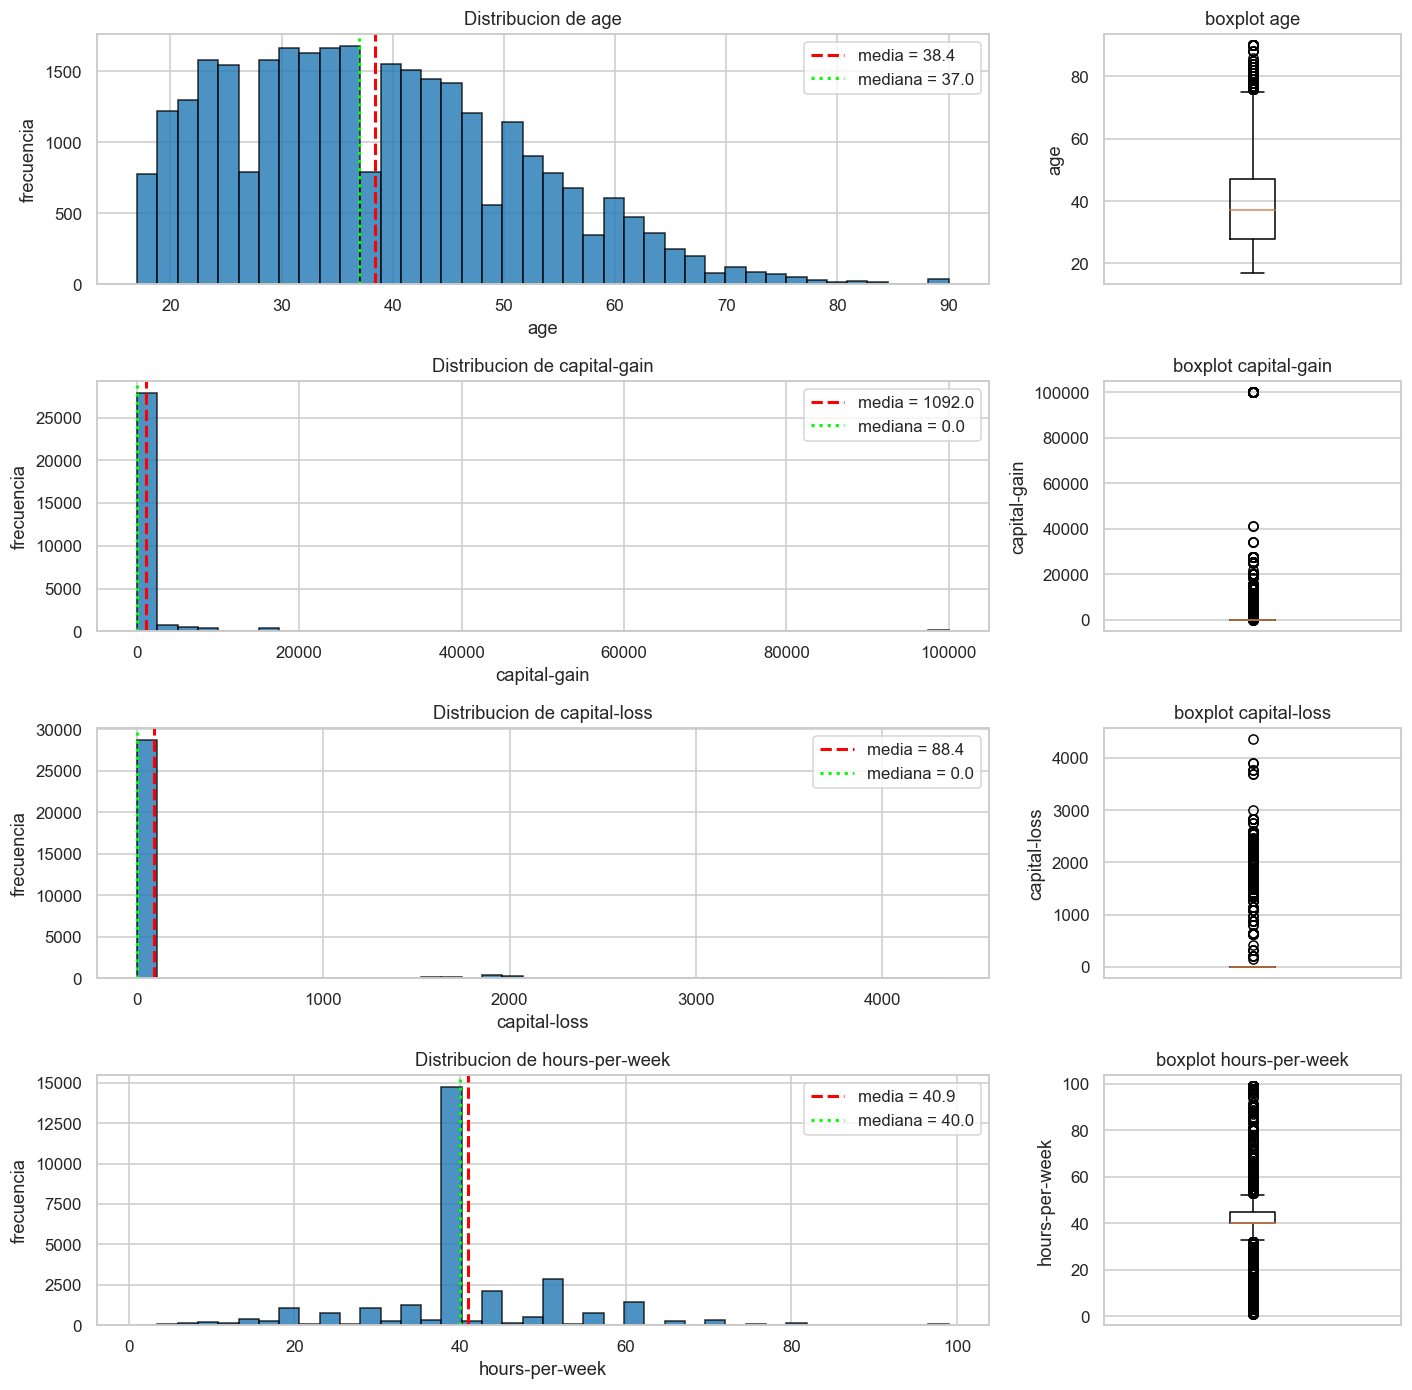

In [15]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(13, 3.2 * len(num_cols)),
                         gridspec_kw={"width_ratios": [3, 1]})
for (ax_h, ax_b), col in zip(axes, num_cols):
    s = train[col]
    ax_h.hist(s, bins=40, color="tab:blue", edgecolor="black", alpha=0.8)
    ax_h.axvline(s.mean(), color="red", ls="--", lw=2, label=f"media = {s.mean():.1f}")
    ax_h.axvline(s.median(), color="lime", ls=":", lw=2, label=f"mediana = {s.median():.1f}")
    ax_h.set_title(f"Distribucion de {col}")
    ax_h.set_xlabel(col); ax_h.set_ylabel("frecuencia"); ax_h.legend()
    ax_b.boxplot(s, vert=True)
    ax_b.set_title(f"boxplot {col}")
    ax_b.set_ylabel(col)
    ax_b.set_xticks([])
plt.tight_layout()
plt.show()

capital-gain y capital-loss estan dominadas por ceros, miro cuanto pesan

In [16]:
for col in ["capital-gain", "capital-loss"]:
    pct_cero = (train[col] == 0).mean() * 100
    sub = train.loc[train[col] > 0, col]
    print(f"{col}: {pct_cero:.1f}% en cero | no-cero -> n={len(sub)}, "
          f"mediana={sub.median():.0f}, max={sub.max()}")

capital-gain: 91.6% en cero | no-cero -> n=2538, mediana=7298, max=99999
capital-loss: 95.3% en cero | no-cero -> n=1427, mediana=1887, max=4356


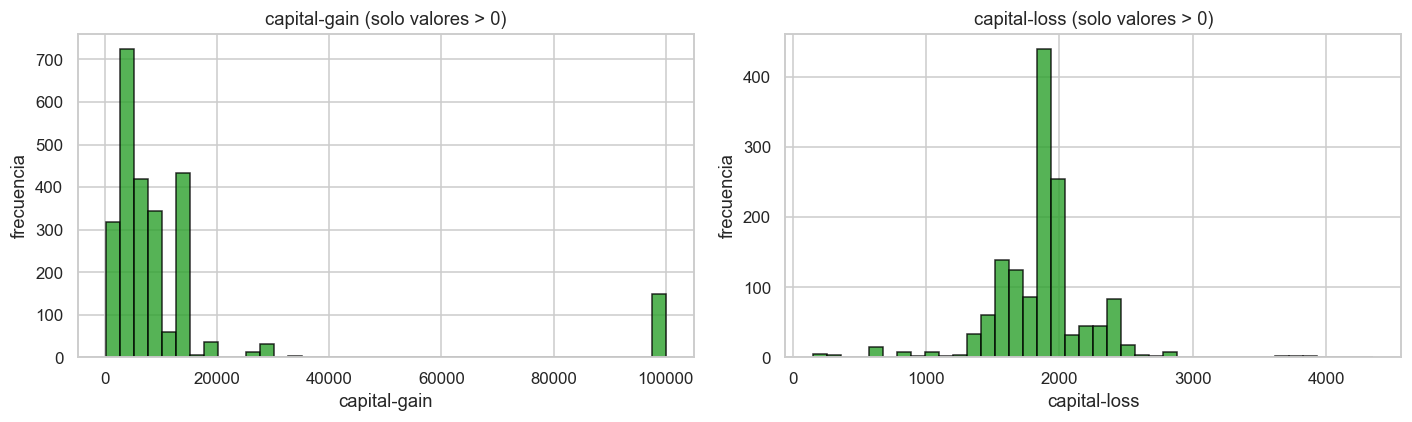

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["capital-gain", "capital-loss"]):
    sub = train.loc[train[col] > 0, col]
    ax.hist(sub, bins=40, color="tab:green", edgecolor="black", alpha=0.8)
    ax.set_title(f"{col} (solo valores > 0)")
    ax.set_xlabel(col); ax.set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:
- age va de 17 a 90, con más gente joven y adulta que gente mayor.
- hours-per-week se concentra fuertemente en 40 (jornada completa), con colas hacia part-time y hacia jornadas muy largas.
- capital-gain y capital-loss son casi todo ceros (más del 90%).

### Numéricas frente a income

Ahora miro cada numérica separada por clase, para ver cuáles ayudan a distinguir ingresos altos de bajos.

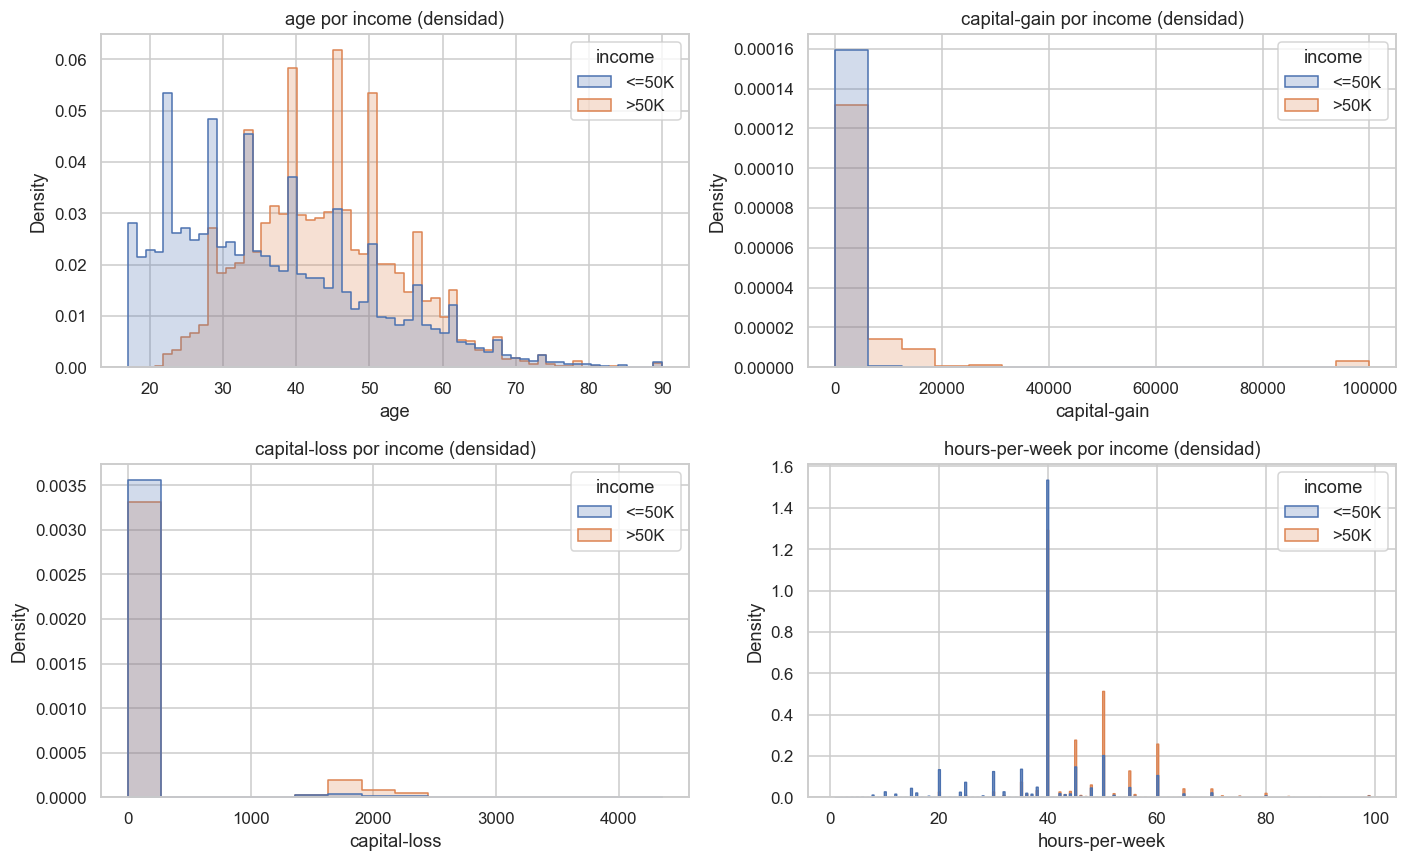

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=train, x=col, hue="income", stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{col} por income (densidad)")
plt.tight_layout()
plt.show()

Observaciones:

- La gente con >50K tiende a tener mayor edad y a trabajar más horas.
- En capital-gain casi todos los valores altos pertenecen a la clase >50K.

### Categóricas de baja cardinalidad (menos de 10 categorías únicas)

Miro frecuencias de cada categoría

In [19]:
cat_baja = ["sex", "race", "relationship", "workclass", "marital-status"]
for c in cat_baja:
    print(f"{c}: {train[c].nunique()} categorias unicas")

sex: 2 categorias unicas
race: 5 categorias unicas
relationship: 6 categorias unicas
workclass: 7 categorias unicas
marital-status: 7 categorias unicas


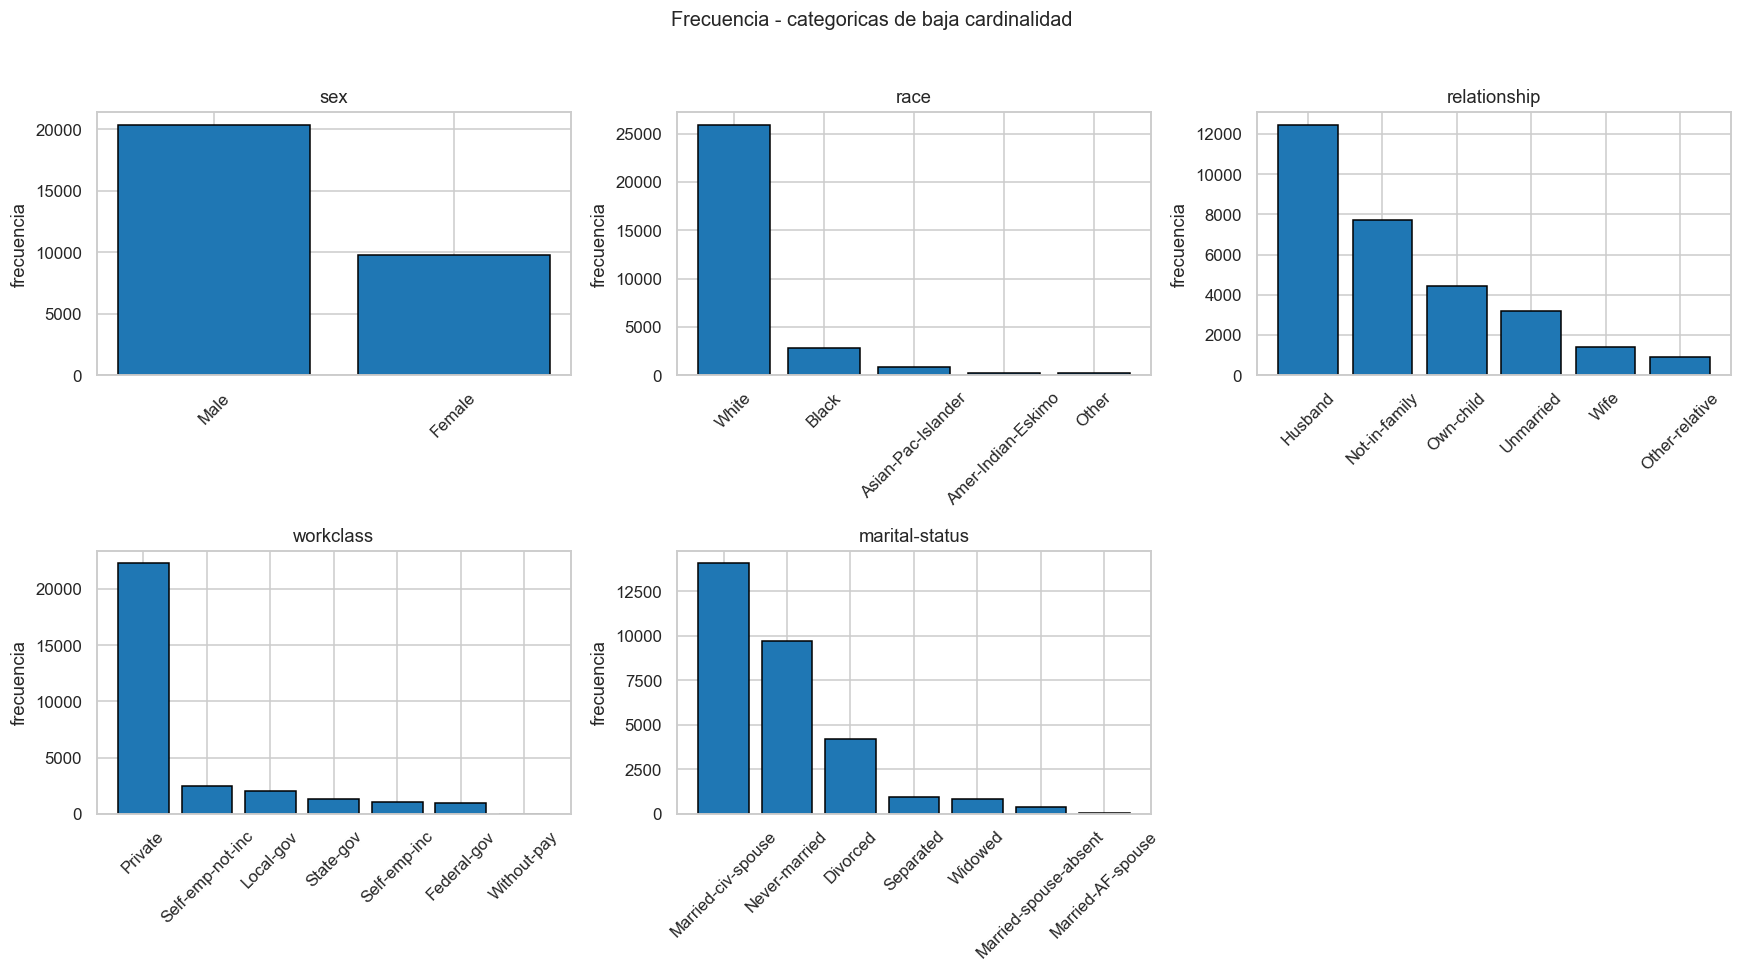

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_baja):
    vc = train[col].value_counts()
    ax.bar(vc.index, vc.values, color="tab:blue", edgecolor="black")
    ax.set_title(col); ax.set_ylabel("frecuencia")
    ax.tick_params(axis="x", rotation=45)
for ax in axes.flat[len(cat_baja):]:
    ax.axis("off")
fig.suptitle("Frecuencia - categoricas de baja cardinalidad", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observaciones:

- sex: hay más hombres que mujeres.
- race: muy dominada por White.
- relationship: la más frecuente es Husband, seguida de Not-in-family y Own-child.
- workclass: la gran mayoría es Private.
- marital-status: se reparte sobre todo entre Married-civ-spouse y Never-married.

### Categóricas de alta cardinalidad (10 o más categorías únicas)

Miro frecuencias de cada categoría

In [21]:
cat_alta = ["occupation", "education", "native-country", "skill-profile"]
for c in cat_alta:
    print(f"{c}: {train[c].nunique()} categorias unicas")

occupation: 14 categorias unicas
education: 16 categorias unicas
native-country: 41 categorias unicas
skill-profile: 80 categorias unicas


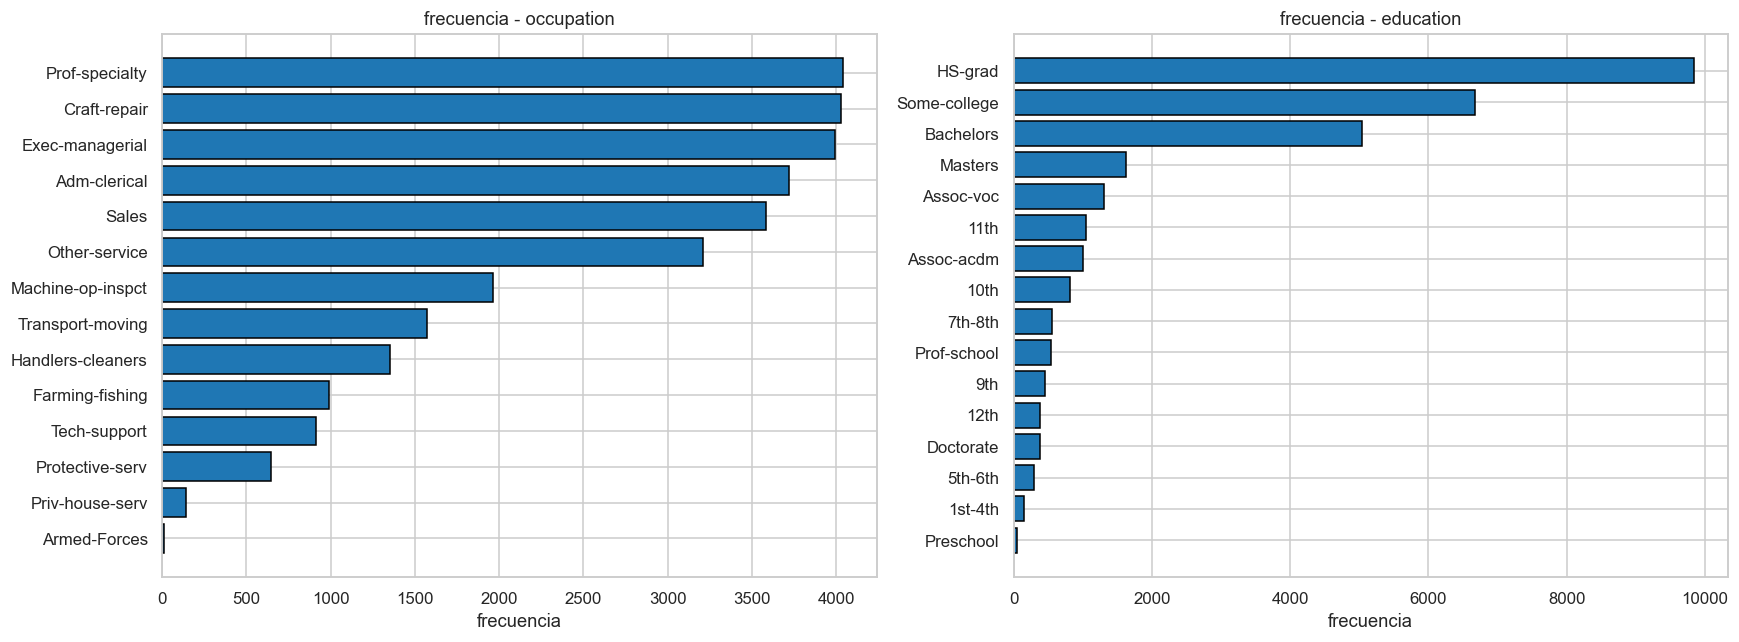

In [22]:
# occupation (14) y education (16): muestro todas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["occupation", "education"]):
    vc = train[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"frecuencia - {col}")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

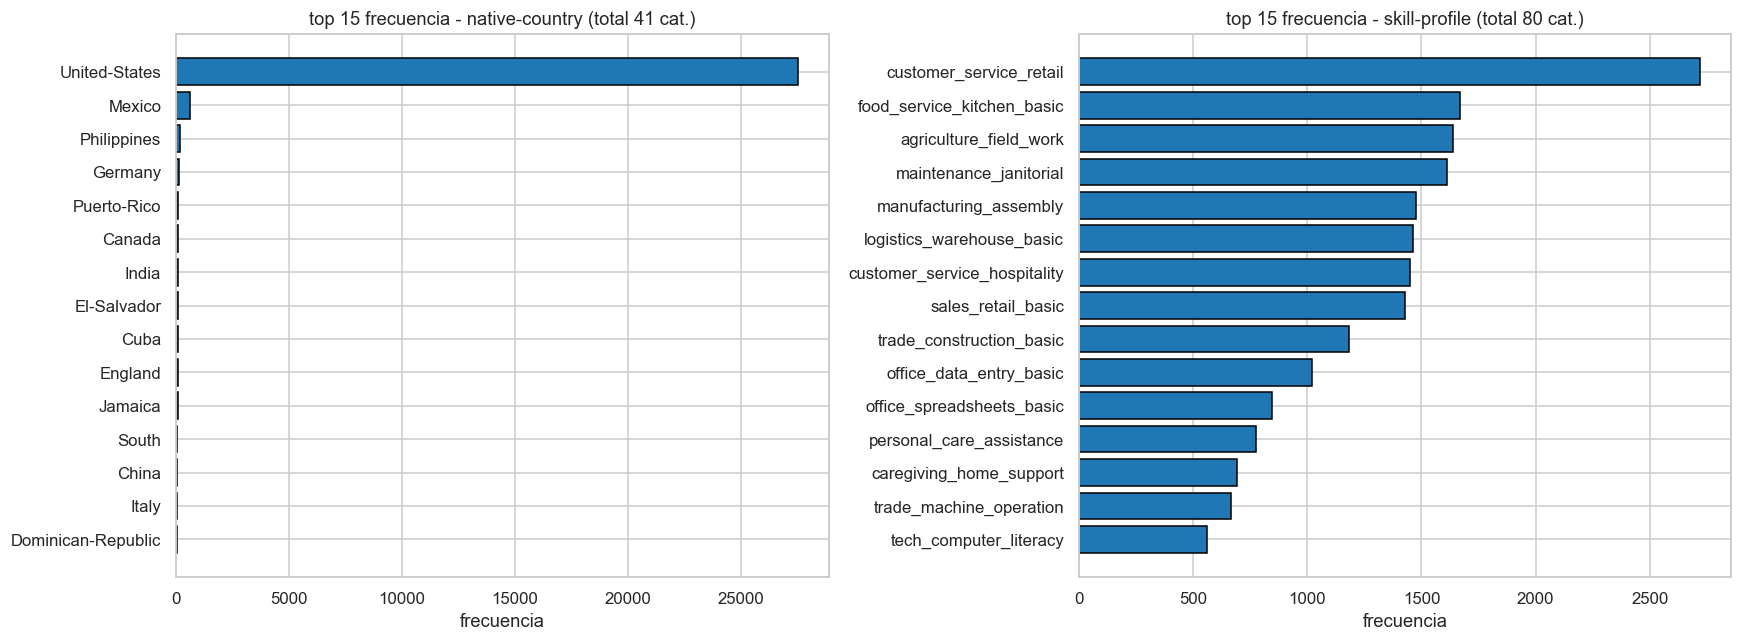

In [23]:
# native-country (41) y skill-profile (80): top 15 por frecuencia
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["native-country", "skill-profile"]):
    vc = train[col].value_counts()
    top = vc.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color="tab:blue", edgecolor="black")
    ax.set_title(f"top 15 frecuencia - {col} (total {train[col].nunique()} cat.)")
    ax.set_xlabel("frecuencia")
plt.tight_layout()
plt.show()

Observaciones:

- occupation: frecuencias repartidas, sin una categoría que domine.
- education: varias categorías con mayor frecuencia (HS-grad, Some-college, Bachelors) y otras muy chicas (Preschool, 1st-4th).
- native-country: fuertemente dominada por United-States.
- skill-profile: la frecuencia se reparte entre muchas categorías, ninguna domina de forma extrema.

### Decisión final

Con lo visto del EDA defino la transformación de cada variable:

- Numéricas (age, capital-gain, capital-loss, hours-per-week): estandarización (media 0, desvío 1).

- Categóricas de baja cardinalidad (sex, race, relationship, workclass, marital-status):
    - sex: codificación binaria 0/1. Al tener solo dos valores, una única columna alcanza y one-hot sería redundante.
    - race, relationship, workclass, marital-status: one-hot. Son pocas categorías (entre 5 y 7), así que el one-hot agrega pocas columnas y no impone un orden que no existe.

- Categóricas de alta cardinalidad (occupation, education, native-country, skill-profile):
    - occupation: embedding. Tiene 14 categorías sin orden natural. El embedding aprende una representación vectorial en lugar de sumar 14 columnas one-hot.
    - education: ordinal, de menor a mayor nivel educativo (Preschool < 1st-4th < ... < Masters < Doctorate). Tiene un orden interno claro que conviene aprovechar.
    - native-country: embedding. 41 categorías muy concentradas en un valor (United-States). El embedding evita las 41 columnas del one-hot y da representación a las categorías raras.
    - skill-profile: embedding. Misma lógica que las anteriores, pero con 80 categorías repartidas, donde el one-hot sería más costoso y disperso.
    
- Target (income): codificación binaria 0/1.

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

### Transformaciones

Implemento las transformaciones que definí al final del EDA

In [24]:
import random

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [25]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"device: {device}")

device: mps


In [26]:
# orden de education, de menor a mayor nivel educativo
orden_education = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm",
    "Bachelors", "Masters", "Prof-school", "Doctorate",
]
mapa_education = {cat: i for i, cat in enumerate(orden_education)}

cols_onehot = ["race", "relationship", "workclass", "marital-status"]
cols_emb = ["occupation", "native-country", "skill-profile"]

# vocabularios de embeddings armados sobre train
vocabs = {c: {cat: i for i, cat in enumerate(sorted(train[c].unique()))} for c in cols_emb}
cardinalidades = [len(vocabs[c]) for c in cols_emb]

print(f"cardinalidades embeddings: {dict(zip(cols_emb, cardinalidades))}")

cardinalidades embeddings: {'occupation': 14, 'native-country': 41, 'skill-profile': 80}


In [27]:
# scaler ajustado solo en train (numericas + education ordinal)
cols_escalar = num_cols + ["education-ord"]
train_esc = train.assign(**{"education-ord": train["education"].map(mapa_education)})
scaler = StandardScaler().fit(train_esc[cols_escalar])

# columnas one-hot de referencia (las de train)
cols_dummies = pd.get_dummies(train[cols_onehot]).columns


def preparar(df):
    d = df.assign(**{"education-ord": df["education"].map(mapa_education)})
    escaladas = pd.DataFrame(scaler.transform(d[cols_escalar]), columns=cols_escalar, index=d.index)
    sexo = (d["sex"] == "Male").astype(float).rename("sex")
    dummies = pd.get_dummies(d[cols_onehot]).reindex(columns=cols_dummies, fill_value=0).astype(float)
    X_num = pd.concat([escaladas, sexo, dummies], axis=1)
    X_cat = pd.concat([d[c].map(vocabs[c]) for c in cols_emb], axis=1)
    y = (d["income"] == ">50K").astype(float)
    return (
        torch.tensor(X_num.to_numpy(), dtype=torch.float32),
        torch.tensor(X_cat.to_numpy(), dtype=torch.long),
        torch.tensor(y.to_numpy(), dtype=torch.float32),
    )

In [28]:
X_num_tr, X_cat_tr, y_tr = preparar(train)
X_num_va, X_cat_va, y_va = preparar(val)
print(f"X_num train: {tuple(X_num_tr.shape)} | X_cat train: {tuple(X_cat_tr.shape)}")
print(f"X_num val:   {tuple(X_num_va.shape)} | X_cat val:   {tuple(X_cat_va.shape)}")

X_num train: (30162, 31) | X_cat train: (30162, 3)
X_num val:   (15060, 31) | X_cat val:   (15060, 3)


### Dataset y DataLoader

Armo el Dataset y DataLoader para cada set:
- train con mini-batches de 512 y shuffle
- validación con el mismo tamaño de batch pero sin shuffle, porque ahí solo evalúo.

In [29]:
batch_size = 512

ds_train = TensorDataset(X_num_tr, X_cat_tr, y_tr)
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

ds_val = TensorDataset(X_num_va, X_cat_va, y_va)
dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

print(f"batches por época: train {len(dl_train)} | val {len(dl_val)}")

batches por época: train 59 | val 30


### Modelo

Para las dimensiones de los embeddings uso la [heurística de fastai](https://forums.fast.ai/t/determining-dimensions-of-embeddings/55552):

- occupation (14 categorías): dimensión 7
- native-country (41): dimensión 13
- skill-profile (80): dimensión 19

In [30]:
def dim_embedding(n):
    # https://github.com/fastai/fastai/blob/96c5927648ecf83f0bc9ab601f672d3c0ffe0059/fastai/tabular/data.py#L13
    return min(600, round(1.6 * n**0.56))


dims_emb = [dim_embedding(n) for n in cardinalidades]
print(f"dimensiones de embedding: {dict(zip(cols_emb, dims_emb))}")

dimensiones de embedding: {'occupation': 7, 'native-country': 13, 'skill-profile': 19}


La red concatena los tres embeddings con el resto de las features y pasa por 2 capas ocultas de 64 y 32 neuronas con ReLU, cada una seguida de dropout 0.4.

La salida es una sola neurona sin activación. Devuelve el logit y la sigmoide queda dentro de la función de costo.

In [31]:
class ModeloEmbeddings(nn.Module):
    def __init__(self, n_features_num, cardinalidades, dims_emb, p_dropout=0.4):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(n, d) for n, d in zip(cardinalidades, dims_emb)]
        )
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, std=0.01)
        entrada = n_features_num + sum(dims_emb)
        self.mlp = nn.Sequential(
            nn.Linear(entrada, 64), nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(p_dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_num], dim=1)
        return self.mlp(x).squeeze(1)

In [32]:
modelo = ModeloEmbeddings(X_num_tr.shape[1], cardinalidades, dims_emb).to(device)
print(modelo)

ModeloEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(14, 7)
    (1): Embedding(41, 13)
    (2): Embedding(80, 19)
  )
  (mlp): Sequential(
    (0): Linear(in_features=70, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [33]:
n_params = sum(p.numel() for p in modelo.parameters())
print(f"parámetros entrenables: {n_params:}")

parámetros entrenables: 8808


### Entrenamiento

Decisiones:

- Optimizador: Adam. 
- Función de costo: el problema es binario con una sola neurona de salida, así que corresponde Binary Cross Entropy. Uso  [BCEWithLogitsLoss](https://docs.pytorch.org/docs/2.13/generated/torch.nn.BCEWithLogitsLoss.html), que tiene la sigmoide con la BCE dentro de la misma operación para mejor estabilidad numérica. El modelo devuelve logit y la sigmoide se aplica luego al predecir.
- Desbalance del target: la clase >50K es el 25% del train y la consigna evalúa F1 macro, así que le paso pos_weight como explica la documentacion oficial de pytorch para BCEWithLogitsLoss. 
- Hiperparámetros: como en el TP1, busco learning rate y cantidad de épocas con Optuna, maximizando el F1 macro de validación.

In [34]:
n_pos = (y_tr == 1).sum().item()
n_neg = (y_tr == 0).sum().item()
pos_weight = torch.tensor([n_neg / n_pos], device=device)
print(f"pos_weight: {pos_weight.item():.2f}")

pos_weight: 3.02


In [35]:
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def entrenar(modelo, lr, epocas, verbose=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    hist = {k: [] for k in ["loss_train", "loss_val", "acc_train", "acc_val", "f1_train", "f1_val"]}
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb_num, xb_cat, yb in dl_train:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            loss = bce_loss(modelo(xb_num, xb_cat), yb)
            optimizador.zero_grad(set_to_none=True)
            loss.backward()
            optimizador.step()

        loss_tr, acc_tr, f1_tr, _ = evaluar(modelo, dl_train)
        loss_va, acc_va, f1_va, _ = evaluar(modelo, dl_val)
        for k, v in zip(hist, [loss_tr, loss_va, acc_tr, acc_va, f1_tr, f1_va]):
            hist[k].append(v)
        if verbose and (epoca % 5 == 0 or epoca == 1):
            print(f"época {epoca:3d} | loss train {loss_tr:.4f} val {loss_va:.4f} | "
                  f"acc val {acc_va:.4f} | F1 macro val {f1_va:.4f}")
    return hist


def evaluar(modelo, dl):
    modelo.eval()
    loss_total, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb_num, xb_cat, yb in dl:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            logits = modelo(xb_num, xb_cat)
            loss_total += bce_loss(logits, yb).item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append((torch.sigmoid(logits) >= 0.5).float().cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (loss_total / len(dl.dataset),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro"),
            y_pred)


def modelo_nuevo():
    torch.manual_seed(SEED)
    return ModeloEmbeddings(X_num_tr.shape[1], cardinalidades, dims_emb).to(device)

#### Búsqueda de hiperparámetros con Optuna

Busco learning rate y cantidad de épocas con 15 trials. Cada trial entrena un modelo desde cero con la misma semilla y devuelve el F1 macro de validación. El study queda guardado en un SQLite local (`optuna_tp2.db`), así las re-ejecuciones del notebook cargan el resultado en lugar de repetir la búsqueda.

In [36]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 15


def objetivo(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    epocas = trial.suggest_int("epocas", 10, 50)
    hist = entrenar(modelo_nuevo(), lr, epocas)
    return hist["f1_val"][-1]


study = optuna.create_study(
    study_name="tp2_embeddings",
    storage="sqlite:///optuna_tp2.db",
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    load_if_exists=True,
)

faltan = N_TRIALS - len(study.trials)
if faltan > 0:
    study.optimize(objetivo, n_trials=faltan, show_progress_bar=True)

print(f"trials en el study: {len(study.trials)}")
print(f"mejor F1 macro val: {study.best_value:.4f}")
print(f"mejores hiperparámetros: {study.best_params}")


trials en el study: 15
mejor F1 macro val: 0.8361
mejores hiperparámetros: {'lr': 0.0004059611610484307, 'epocas': 31}


#### Entrenamiento final

Reentreno desde cero con los mejores hiperparámetros que encontró optuna, guardando las métricas por época para hacer las curvas.

In [37]:
import time

inicio = time.perf_counter()
modelo = modelo_nuevo()
hist = entrenar(modelo, study.best_params["lr"], study.best_params["epocas"], verbose=True)
tiempo_emb = time.perf_counter() - inicio
best_params_epocas = study.best_params["epocas"]
print(f"tiempo de entrenamiento: {tiempo_emb:.1f} s")


época   1 | loss train 0.8905 val 0.8878 | acc val 0.7457 | F1 macro val 0.7215


época   5 | loss train 0.4707 val 0.4712 | acc val 0.8596 | F1 macro val 0.8265


época  10 | loss train 0.4509 val 0.4568 | acc val 0.8655 | F1 macro val 0.8327


época  15 | loss train 0.4450 val 0.4530 | acc val 0.8639 | F1 macro val 0.8315


época  20 | loss train 0.4411 val 0.4516 | acc val 0.8671 | F1 macro val 0.8343


época  25 | loss train 0.4391 val 0.4512 | acc val 0.8620 | F1 macro val 0.8301


época  30 | loss train 0.4360 val 0.4505 | acc val 0.8681 | F1 macro val 0.8355


tiempo de entrenamiento: 23.7 s


### Curvas de loss, accuracy y F1 macro por época

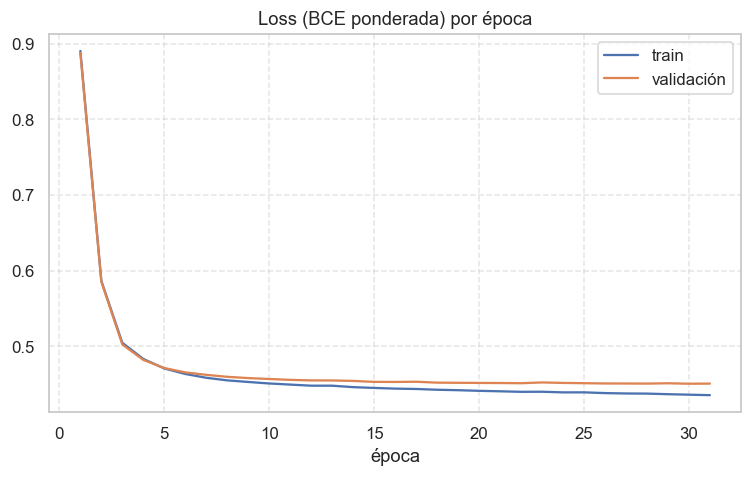

In [38]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, best_params_epocas + 1), hist["loss_train"], label="train")
plt.plot(range(1, best_params_epocas + 1), hist["loss_val"], label="validación")
plt.title("Loss (BCE ponderada) por época")
plt.xlabel("época")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

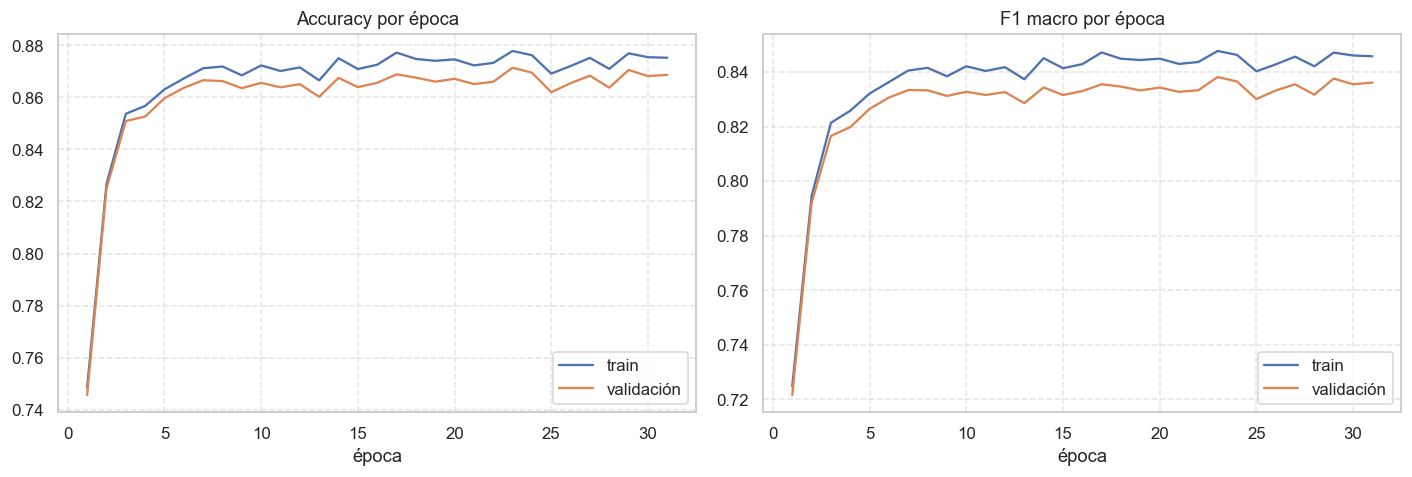

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metrica, titulo in [
    (axes[0], "acc", "Accuracy por época"),
    (axes[1], "f1", "F1 macro por época"),
]:
    ax.plot(range(1, best_params_epocas + 1), hist[f"{metrica}_train"], label="train")
    ax.plot(range(1, best_params_epocas + 1), hist[f"{metrica}_val"], label="validación")
    ax.set_title(titulo)
    ax.set_xlabel("época")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend()
plt.tight_layout()
plt.show()

La loss de validación encuentra su piso en las primeras épocas y de ahí en más queda plana, con una suba apenas perceptible sobre el final. La de train sigue bajando despacio todo el entrenamiento, así que hay sobreajuste, pero leve: la brecha entre las dos curvas queda contenida, en parte por el dropout y en parte porque el modelo es chico.

Las curvas de accuracy y F1 macro muestran lo mismo desde el otro lado: validación se ameseta enseguida y después oscila alrededor de ese nivel sin caerse, mientras train sigue subiendo de a poco. Las oscilaciones época a época son ruido del entrenamiento por mini-batches, no un patrón.

### Evaluación en validación

In [40]:
_, _, _, pred_va = evaluar(modelo, dl_val)
y_va_np = y_va.numpy()

etiquetas = ["<=50K", ">50K"]
print(classification_report(y_va_np, pred_va, target_names=etiquetas, digits=4))

              precision    recall  f1-score   support

       <=50K     0.9508    0.8709    0.9091     11360
        >50K     0.6849    0.8616    0.7631      3700

    accuracy                         0.8686     15060
   macro avg     0.8178    0.8662    0.8361     15060
weighted avg     0.8855    0.8686    0.8732     15060



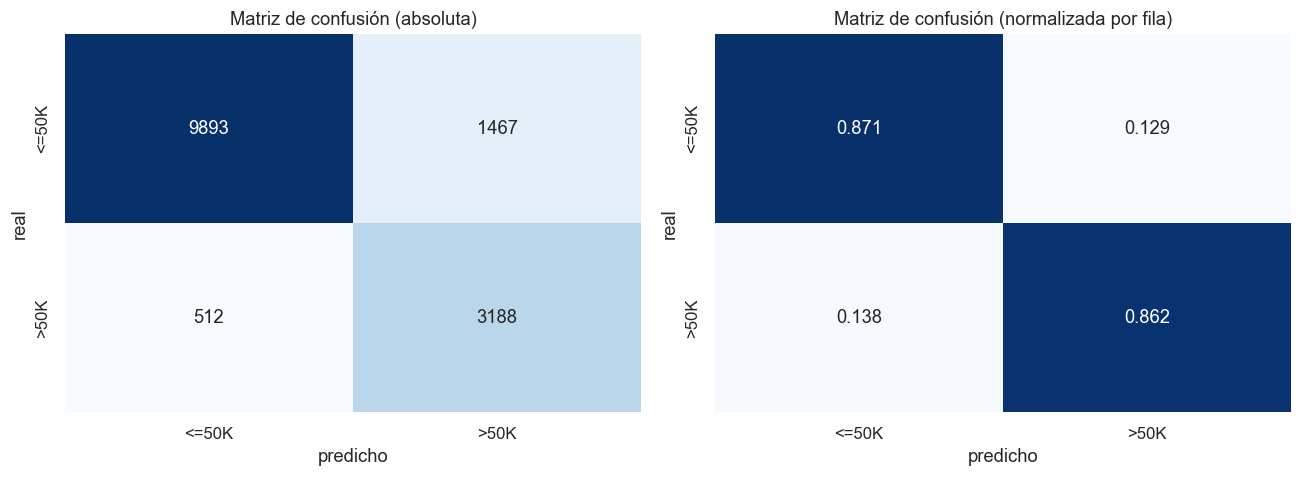

In [41]:
cm_abs = confusion_matrix(y_va_np, pred_va)
cm_norm = confusion_matrix(y_va_np, pred_va, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cm, fmt, titulo in [
    (axes[0], cm_abs, "d", "Matriz de confusión (absoluta)"),
    (axes[1], cm_norm, ".3f", "Matriz de confusión (normalizada por fila)"),
]:
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                xticklabels=etiquetas, yticklabels=etiquetas, ax=ax)
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

La matriz normalizada por fila muestra el recall de cada clase, y las dos quedan en niveles parecidos. Ahí se ve el efecto del `pos_weight`: sin compensar el desbalance, lo esperable era un recall bastante más bajo en la clase minoritaria. El costo aparece en la precisión de >50K, que queda bastante por debajo de la de <=50K, porque el modelo marca como >50K a una parte de gente que en realidad gana menos. Para la métrica que pide el TP (F1 macro) el intercambio conviene.

En resumen: el modelo con embeddings queda con la accuracy y el F1 macro que muestran el classification report y las curvas, entrenado con el learning rate y las épocas que eligió Optuna. Estos resultados quedan como referencia para compararlos con el modelo one-hot del punto c).

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

### Transformaciones para el modelo one-hot

Para este segundo modelo reutilizo el pipeline del punto b) y solo cambio la representación de `occupation`, `native-country` y `skill-profile`: en lugar de índices para embeddings, las paso a one-hot con las categorías vistas en train, igual que hice con el resto de las categóricas. El resultado es una única matriz de entrada, bastante más ancha que la del modelo anterior porque cada categoría de esas tres variables ahora ocupa su propia columna.

In [42]:
# one-hot de las tres variables que antes iban a embeddings (categorías de train)
cols_dummies_emb = pd.get_dummies(train[cols_emb]).columns


def preparar_onehot(df):
    X_num, _, y = preparar(df)
    dummies_emb = (
        pd.get_dummies(df[cols_emb])
        .reindex(columns=cols_dummies_emb, fill_value=0)
        .astype(float)
    )
    X = torch.cat([X_num, torch.tensor(dummies_emb.to_numpy(), dtype=torch.float32)], dim=1)
    return X, y


X_tr_oh, y_tr_oh = preparar_onehot(train)
X_va_oh, y_va_oh = preparar_onehot(val)
print(f"X train: {tuple(X_tr_oh.shape)} | X val: {tuple(X_va_oh.shape)}")


X train: (30162, 166) | X val: (15060, 166)


Armo los DataLoader con el mismo tamaño de batch que en el punto b), así la comparación de tiempos de entrenamiento del punto d) es directa.

In [43]:
ds_train_oh = TensorDataset(X_tr_oh, y_tr_oh)
ds_val_oh = TensorDataset(X_va_oh, y_va_oh)
dl_train_oh = DataLoader(ds_train_oh, batch_size=512, shuffle=True)
dl_val_oh = DataLoader(ds_val_oh, batch_size=512)


### Modelo sin embeddings

La consigna pide mantener la arquitectura del punto b) tal cual: mismas capas ocultas, misma cantidad de neuronas por capa y ReLU como activación, pero sin ninguna capa de dropout ni otra regularización interna. Lo que sí cambia es la capa de entrada: como el one-hot expande cada variable en una columna por categoría, la primera capa lineal recibe muchas más entradas y su matriz de pesos crece en proporción. Abajo imprimo el modelo y la cantidad de parámetros para compararla después con la del modelo con embeddings.

In [44]:
class ModeloOneHot(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.mlp(x).squeeze(1)


def modelo_nuevo_oh():
    torch.manual_seed(SEED)
    return ModeloOneHot(X_tr_oh.shape[1]).to(device)


modelo_oh = modelo_nuevo_oh()
print(modelo_oh)
n_params_oh = sum(p.numel() for p in modelo_oh.parameters())
print(f"parámetros entrenables: {n_params_oh}")


ModeloOneHot(
  (mlp): Sequential(
    (0): Linear(in_features=166, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
parámetros entrenables: 12801


### Entrenamiento

Entreno con la misma loss ponderada y el mismo optimizador que en el punto b), y reutilizo el learning rate y las épocas que encontró Optuna para el modelo con embeddings. La idea es que la única diferencia entre los dos experimentos sea la representación de la entrada: si buscara hiperparámetros nuevos para este modelo, ya no sabría si las diferencias en los resultados vienen de la representación o de la búsqueda. Las funciones de entrenamiento y evaluación son las mismas de antes adaptadas a que ahora el modelo recibe un único tensor. También mido el tiempo total de entrenamiento, que entra en la comparación del punto d).

In [45]:
def evaluar_oh(modelo, dl):
    modelo.eval()
    loss_total, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = modelo(xb)
            loss_total += bce_loss(logits, yb).item() * len(yb)
            y_true.append(yb.cpu())
            y_pred.append((torch.sigmoid(logits) >= 0.5).float().cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (loss_total / len(dl.dataset),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro"),
            y_pred)


def entrenar_oh(modelo, lr, epocas, verbose=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    hist = {k: [] for k in ["loss_train", "loss_val", "acc_train", "acc_val", "f1_train", "f1_val"]}
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb, yb in dl_train_oh:
            xb, yb = xb.to(device), yb.to(device)
            loss = bce_loss(modelo(xb), yb)
            optimizador.zero_grad(set_to_none=True)
            loss.backward()
            optimizador.step()

        loss_tr, acc_tr, f1_tr, _ = evaluar_oh(modelo, dl_train_oh)
        loss_va, acc_va, f1_va, _ = evaluar_oh(modelo, dl_val_oh)
        for k, v in zip(hist, [loss_tr, loss_va, acc_tr, acc_va, f1_tr, f1_va]):
            hist[k].append(v)
        if verbose and (epoca % 5 == 0 or epoca == 1):
            print(f"época {epoca:3d} | loss train {loss_tr:.4f} val {loss_va:.4f} | "
                  f"acc val {acc_va:.4f} | F1 macro val {f1_va:.4f}")
    return hist


In [46]:
inicio = time.perf_counter()
modelo_oh = modelo_nuevo_oh()
hist_oh = entrenar_oh(modelo_oh, study.best_params["lr"], best_params_epocas, verbose=True)
tiempo_oh = time.perf_counter() - inicio
print(f"tiempo de entrenamiento: {tiempo_oh:.1f} s")


época   1 | loss train 0.9048 val 0.9011 | acc val 0.8099 | F1 macro val 0.7747


época   5 | loss train 0.4690 val 0.4691 | acc val 0.8601 | F1 macro val 0.8262


época  10 | loss train 0.4433 val 0.4515 | acc val 0.8647 | F1 macro val 0.8319


época  15 | loss train 0.4349 val 0.4499 | acc val 0.8665 | F1 macro val 0.8334


época  20 | loss train 0.4300 val 0.4504 | acc val 0.8676 | F1 macro val 0.8350


época  25 | loss train 0.4273 val 0.4516 | acc val 0.8631 | F1 macro val 0.8309


época  30 | loss train 0.4239 val 0.4526 | acc val 0.8637 | F1 macro val 0.8314


tiempo de entrenamiento: 14.5 s


### Curvas de loss, accuracy y F1 macro por época

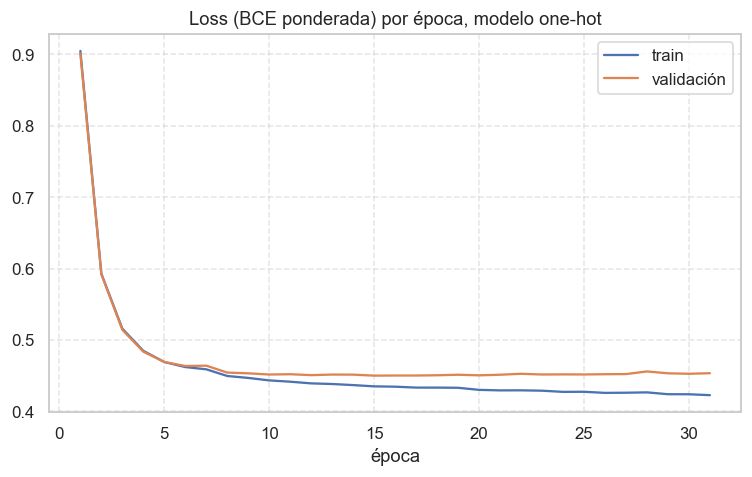

In [47]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, best_params_epocas + 1), hist_oh["loss_train"], label="train")
plt.plot(range(1, best_params_epocas + 1), hist_oh["loss_val"], label="validación")
plt.title("Loss (BCE ponderada) por época, modelo one-hot")
plt.xlabel("época")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


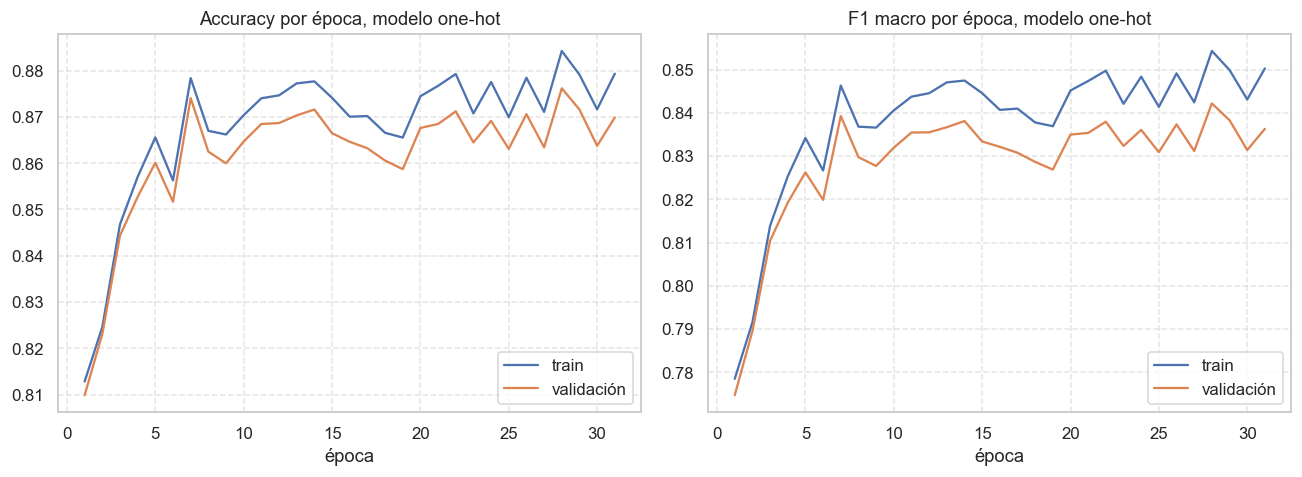

In [48]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
ejes[0].plot(range(1, best_params_epocas + 1), hist_oh["acc_train"], label="train")
ejes[0].plot(range(1, best_params_epocas + 1), hist_oh["acc_val"], label="validación")
ejes[0].set_title("Accuracy por época, modelo one-hot")
ejes[0].set_xlabel("época")
ejes[0].grid(True, ls="--", alpha=0.5)
ejes[0].legend()
ejes[1].plot(range(1, best_params_epocas + 1), hist_oh["f1_train"], label="train")
ejes[1].plot(range(1, best_params_epocas + 1), hist_oh["f1_val"], label="validación")
ejes[1].set_title("F1 macro por época, modelo one-hot")
ejes[1].set_xlabel("época")
ejes[1].grid(True, ls="--", alpha=0.5)
ejes[1].legend()
plt.tight_layout()
plt.show()


Sin dropout el sobreajuste se nota un poco más que en el modelo con embeddings: la loss de train sigue bajando durante todo el entrenamiento mientras la de validación se aplana temprano y sobre el final llega a subir apenas, con una brecha entre curvas algo más ancha que antes. En accuracy y F1 macro pasa lo mismo desde el otro lado, validación se ameseta y oscila alrededor de su nivel mientras train sigue mejorando de a poco. De todas formas la red es tan chica y los datos tantos que la regularización que falta no llega a degradar validación, solo deja de acompañar la mejora de train.

### Classification report

In [49]:
_, _, _, pred_va_oh = evaluar_oh(modelo_oh, dl_val_oh)
print(classification_report(y_va_np, pred_va_oh, target_names=etiquetas, digits=4))


              precision    recall  f1-score   support

       <=50K     0.9469    0.8767    0.9104     11360
        >50K     0.6915    0.8489    0.7622      3700

    accuracy                         0.8699     15060
   macro avg     0.8192    0.8628    0.8363     15060
weighted avg     0.8841    0.8699    0.8740     15060



Los números finales quedan casi calcados a los del modelo con embeddings: misma accuracy a efectos prácticos, mismo F1 macro y el mismo patrón por clase, con recall parejo entre las dos y precisión más baja en >50K por el `pos_weight`. Para este dataset, cambiar la representación de entrada no mueve las métricas.

### Matrices de confusión

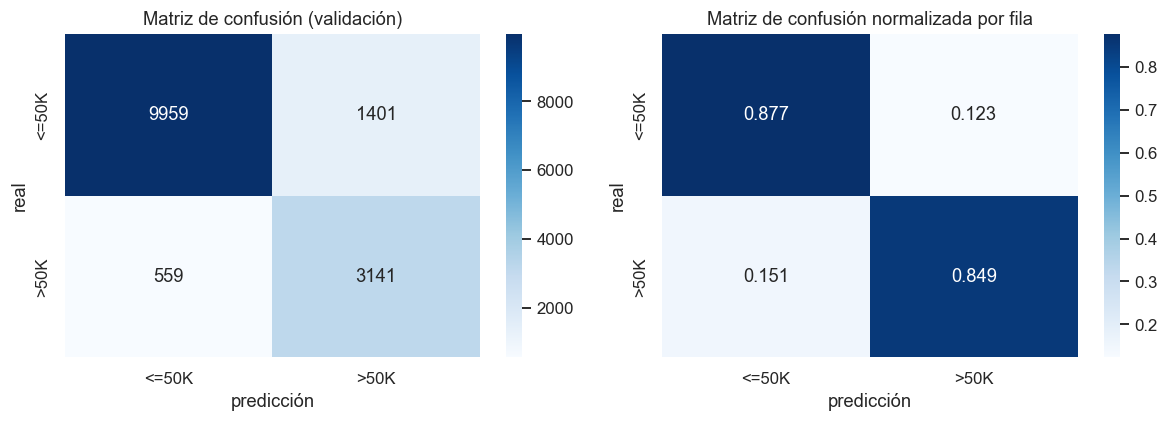

In [50]:
cm_oh = confusion_matrix(y_va_np, pred_va_oh)
cm_oh_norm = confusion_matrix(y_va_np, pred_va_oh, normalize="true")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_oh, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[0])
ejes[0].set_title("Matriz de confusión (validación)")
ejes[0].set_xlabel("predicción")
ejes[0].set_ylabel("real")
sns.heatmap(cm_oh_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ejes[1])
ejes[1].set_title("Matriz de confusión normalizada por fila")
ejes[1].set_xlabel("predicción")
ejes[1].set_ylabel("real")
plt.tight_layout()
plt.show()


Las matrices repiten la foto del punto b): la mayor parte del error está en gente de <=50K que el modelo marca como >50K, que es el costo de compensar el desbalance con `pos_weight`. El recall queda parejo entre clases y no aparece ningún sesgo nuevo por haber reemplazado los embeddings por one-hot.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

Antes de armar la tabla mido también el tiempo de predicción de cada modelo sobre el set de validación completo. Hago varias repeticiones y me quedo con la mejor, con una pasada previa de calentamiento y sincronizando el dispositivo para que la medición no se coma el trabajo pendiente de la GPU.

In [51]:
def sincronizar():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


def benchmark_prediccion(fn, repeticiones=20):
    fn()
    sincronizar()
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        fn()
        sincronizar()
        tiempos.append(time.perf_counter() - inicio)
    return min(tiempos)


X_num_va_d, X_cat_va_d = X_num_va.to(device), X_cat_va.to(device)
X_va_oh_d = X_va_oh.to(device)

modelo.eval()
modelo_oh.eval()
with torch.no_grad():
    t_pred_emb = benchmark_prediccion(lambda: torch.sigmoid(modelo(X_num_va_d, X_cat_va_d)))
    t_pred_oh = benchmark_prediccion(lambda: torch.sigmoid(modelo_oh(X_va_oh_d)))

print(f"predicción sobre validación completa: embeddings {t_pred_emb * 1000:.2f} ms | one-hot {t_pred_oh * 1000:.2f} ms")


predicción sobre validación completa: embeddings 1.59 ms | one-hot 1.11 ms


In [52]:
import io


def tamano_mb(modelo):
    buffer = io.BytesIO()
    torch.save(modelo.state_dict(), buffer)
    return buffer.getbuffer().nbytes / 1024**2


_, acc_emb, f1_emb, _ = evaluar(modelo, dl_val)
_, acc_oh, f1_oh, _ = evaluar_oh(modelo_oh, dl_val_oh)

tabla = pd.DataFrame(
    {
        "con embeddings": [
            X_num_tr.shape[1] + len(cols_emb),
            X_num_tr.shape[1] + sum(dims_emb),
            n_params,
            f"{tamano_mb(modelo):.3f}",
            f"{acc_emb:.4f}",
            f"{f1_emb:.4f}",
            f"{tiempo_emb:.1f}",
            f"{t_pred_emb * 1000:.2f}",
        ],
        "one-hot": [
            X_tr_oh.shape[1],
            X_tr_oh.shape[1],
            n_params_oh,
            f"{tamano_mb(modelo_oh):.3f}",
            f"{acc_oh:.4f}",
            f"{f1_oh:.4f}",
            f"{tiempo_oh:.1f}",
            f"{t_pred_oh * 1000:.2f}",
        ],
    },
    index=[
        "columnas de entrada",
        "entradas al MLP",
        "parámetros entrenables",
        "tamaño guardado (MB)",
        "accuracy (validación)",
        "F1 macro (validación)",
        "tiempo de entrenamiento (s)",
        "predicción sobre validación (ms)",
    ],
)
tabla


,con embeddings,one-hot
columnas de entrada,34,166
entradas al MLP,70,166
parámetros entrenables,8808,12801
tamaño guardado (MB),0.037,0.051
accuracy (validación),0.8686,0.8699
F1 macro (validación),0.8361,0.8363
tiempo de entrenamiento (s),23.7,14.5
predicción sobre validación (ms),1.59,1.11


La tabla deja la comparación bastante clara. En métricas los dos modelos terminan prácticamente empatados: la accuracy y el F1 macro de validación difieren en el orden del ruido entre corridas, y el classification report y las matrices de confusión muestran el mismo patrón de errores. Para este dataset, con cardinalidades moderadas y una sola variable realmente ancha (skill-profile), la representación de entrada no cambia lo que el modelo puede aprender.

Donde sí hay diferencias es en el tamaño. El one-hot expande las tres variables en una columna por categoría, así que la entrada pasa de unas decenas de columnas a varios cientos, casi todas en cero para cada fila. Toda esa anchura extra cae sobre la primera capa lineal, que concentra el crecimiento de parámetros: el modelo one-hot termina bastante más pesado que el de embeddings aunque el resto de la red es idéntico. Los embeddings comprimen cada categoría en un vector denso de pocas dimensiones, y esa compresión es lo que mantiene chica la red. La diferencia se traslada tal cual al disco: el checkpoint del one-hot ocupa más espacio en proporción directa a sus parámetros extra, aunque a esta escala los dos pesan una fracción de megabyte y guardarlos no cuesta nada.

El tiempo de entrenamiento me dio una sorpresa: el modelo one-hot entrenó más rápido, no más lento. Con una red de este tamaño, multiplicar por las columnas adicionales cuesta poco, y el modelo con embeddings paga por otro lado: tres lookups de embedding y una concatenación por batch, operaciones chicas que suman overhead. Esa ventaja de velocidad es un efecto de escala; si las variables tuvieran miles de categorías, la primera capa del one-hot crecería en proporción y la cuenta se daría vuelta. En predicción se repite el mismo patrón: el benchmark sobre el set de validación completo da al one-hot como el más rápido de los dos, porque su forward es una sola cadena de multiplicaciones de matrices mientras que el de embeddings tiene que hacer los lookups y concatenar antes de entrar al MLP. En ambos casos hablamos de milisegundos para miles de filas, así que ninguno tendría problemas en producción.

La falta de dropout también se nota, aunque poco: la brecha entre train y validación del modelo one-hot es algo más ancha y su loss de validación llega a subir sobre el final. Con tan pocos parámetros y tantos datos el sobreajuste no alcanza a costar métricas, pero la tendencia está.

Mi conclusión es que en este problema los dos enfoques rinden igual en lo predictivo, así que la elección pasa por lo demás. El one-hot es más simple de implementar y acá hasta más rápido, pero escala mal: cada categoría nueva agrega una entrada con sus pesos, y con variables de cardinalidad alta la red engorda sin techo. Los embeddings mantienen la entrada compacta, escalan con la dimensión elegida en lugar de con la cardinalidad, y además aprenden una representación donde categorías parecidas quedan cerca, algo que el one-hot no puede hacer porque trata a todas las categorías como igualmente distintas entre sí. Para cardinalidades como las de este TP da casi lo mismo; con catálogos grandes (usuarios, productos, vocabularios) los embeddings son la única opción razonable.